##Weather Forecasting and Seasonal Trend Analysis Using Time Series Models 🌦️
**Group Members:**  
- Abdul Wahab  
- Muhammad Haroon  
- Memona Raize  
- Marwa Shouqat

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
df=pd.read_csv("/content/weatherHistory.csv")

In [ ]:
print(df.head())

                  Formatted Date        Summary Precip Type  Temperature (C)  \
0  2006-04-01 00:00:00.000 +0200  Partly Cloudy        rain         9.472222   
1  2006-04-01 01:00:00.000 +0200  Partly Cloudy        rain         9.355556   
2  2006-04-01 02:00:00.000 +0200  Mostly Cloudy        rain         9.377778   
3  2006-04-01 03:00:00.000 +0200  Partly Cloudy        rain         8.288889   
4  2006-04-01 04:00:00.000 +0200  Mostly Cloudy        rain         8.755556   

   Apparent Temperature (C)  Humidity  Wind Speed (km/h)  \
0                  7.388889      0.89            14.1197   
1                  7.227778      0.86            14.2646   
2                  9.377778      0.89             3.9284   
3                  5.944444      0.83            14.1036   
4                  6.977778      0.83            11.0446   

   Wind Bearing (degrees)  Visibility (km)  Loud Cover  Pressure (millibars)  \
0                   251.0          15.8263         0.0               1015.13  

##STEP 1 — Data Cleaning

In [ ]:
print(df.isnull().sum())

Formatted Date                0
Summary                       0
Precip Type                 517
Temperature (C)               0
Apparent Temperature (C)      0
Humidity                      0
Wind Speed (km/h)             0
Wind Bearing (degrees)        0
Visibility (km)               0
Loud Cover                    0
Pressure (millibars)          0
Daily Summary                 0
dtype: int64


In [ ]:
df['Precip Type'] = df['Precip Type'].fillna('none')


In [ ]:
print(df.isnull().sum())

Formatted Date              0
Summary                     0
Precip Type                 0
Temperature (C)             0
Apparent Temperature (C)    0
Humidity                    0
Wind Speed (km/h)           0
Wind Bearing (degrees)      0
Visibility (km)             0
Loud Cover                  0
Pressure (millibars)        0
Daily Summary               0
dtype: int64


In [ ]:



# Assume df is already loaded
n_rows = len(df)
print("Number of rows in dataset:", n_rows)

# Generate hourly datetime starting from 2006-04-01 00:00
date_range = pd.date_range(start="2006-04-01 00:00", periods=n_rows, freq='H', tz='UTC')
df['DateTime'] = date_range

# Set datetime index
df = df.set_index('DateTime')



Number of rows in dataset: 96453


/tmp/ipython-input-436722761.py:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  date_range = pd.date_range(start="2006-04-01 00:00", periods=n_rows, freq='H', tz='UTC')


In [ ]:
# -----------------------------
# 2. NUMERIC CLEANING
# -----------------------------
num_cols = [
    "Temperature (C)", "Apparent Temperature (C)", "Humidity",
    "Wind Speed (km/h)", "Wind Bearing (degrees)",
    "Visibility (km)", "Loud Cover", "Pressure (millibars)"
]

# Keep only existing numeric columns
num_cols = [c for c in num_cols if c in df.columns]

# Convert to numeric
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='coerce')

# Create Humidity (%) column AFTER numeric conversion
df['Humidity (%)'] = df['Humidity'] * 100
num_cols.append('Humidity (%)')  # Add to numeric columns for plotting/heatmap






In [ ]:
# -----------------------------
# 3. HANDLE CATEGORICAL COLUMNS
# -----------------------------
cat_cols = [c for c in df.columns if c not in num_cols]
for col in cat_cols:
    df[col] = df[col].fillna("none")

In [ ]:
# Ensure the index is datetime-like for resampling
if not pd.api.types.is_datetime64_any_dtype(df.index):
    # Store original index name if it exists
    original_index_name = df.index.name
    # Convert the existing index to datetime, coercing errors
    df.index = pd.to_datetime(df.index, utc=True, errors='coerce')
    # Restore original index name if it was set
    if original_index_name:
        df.index.name = original_index_name
    # Drop rows where index conversion resulted in NaT (Not a Time)
    df = df[df.index.notna()]

# Keep only temperature
ts = df["Temperature (C)"]

# Resample daily & fill missing
ts = ts.resample("D").mean().interpolate()

print(ts.head())
print("Cleaned length:", len(ts))

Formatted Date
2005-12-31 00:00:00+00:00    0.577778
2006-01-01 00:00:00+00:00    4.075000
2006-01-02 00:00:00+00:00    5.263194
2006-01-03 00:00:00+00:00    2.340509
2006-01-04 00:00:00+00:00    2.251852
Freq: D, Name: Temperature (C), dtype: float64
Cleaned length: 4019


##STEP 2 — Exploratory Data Analysis (EDA)

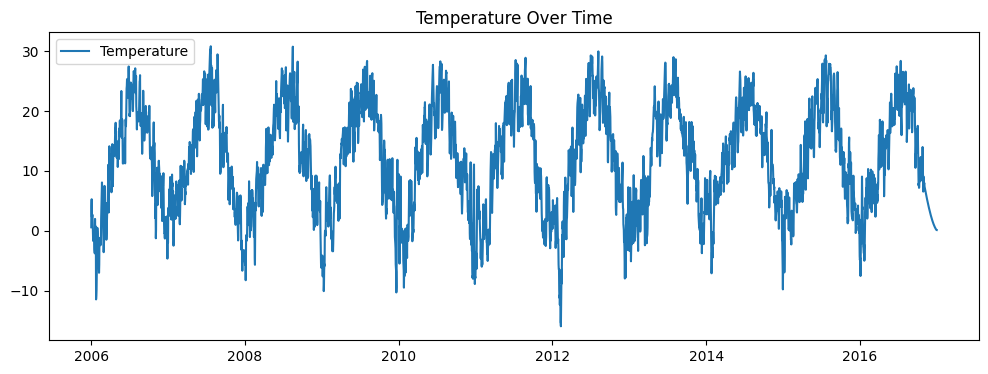

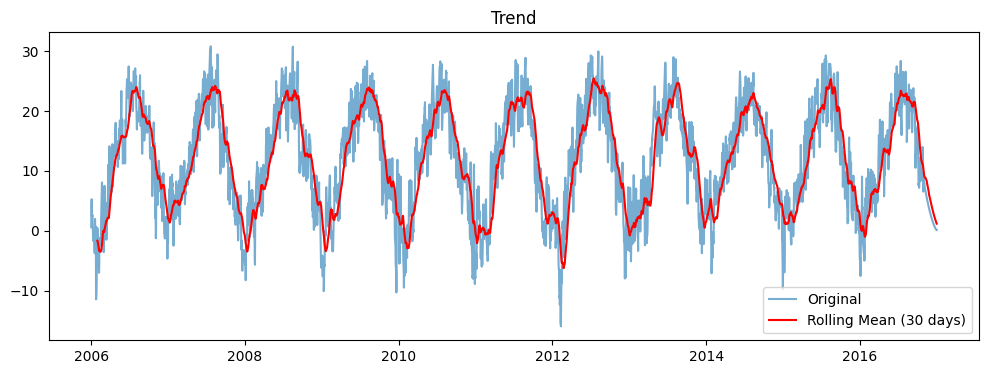

/tmp/ipython-input-772051604.py:19: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = ts.resample("M").mean()


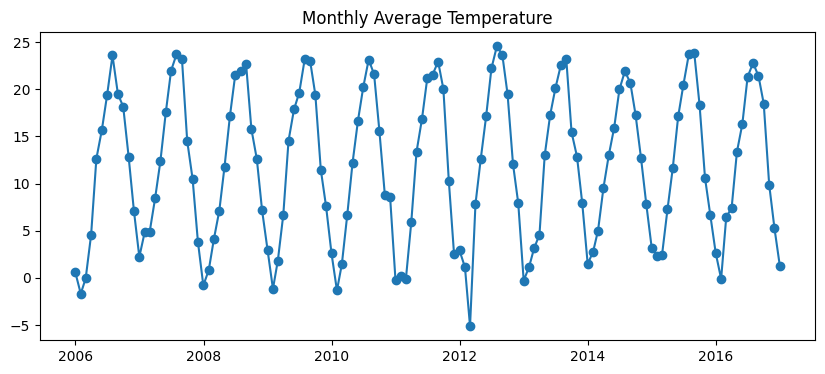

In [ ]:

# === STEP 2: EDA ===

# Plot full series
plt.figure(figsize=(12,4))
plt.plot(ts, label="Temperature")
plt.title("Temperature Over Time")
plt.legend()
plt.show()

# Rolling average
plt.figure(figsize=(12,4))
plt.plot(ts, label="Original", alpha=0.6)
plt.plot(ts.rolling(30).mean(), label="Rolling Mean (30 days)", color="red")
plt.title("Trend")
plt.legend()
plt.show()

# Monthly average
monthly = ts.resample("M").mean()

plt.figure(figsize=(10,4))
plt.plot(monthly, marker="o")
plt.title("Monthly Average Temperature")
plt.show()

##STEP 3 — Stationarity Check (ADF Test + Differencing)

ADF Statistic: -3.9904281476411936
p-value: 0.001461470004492809
After differencing → p-value: 0.0


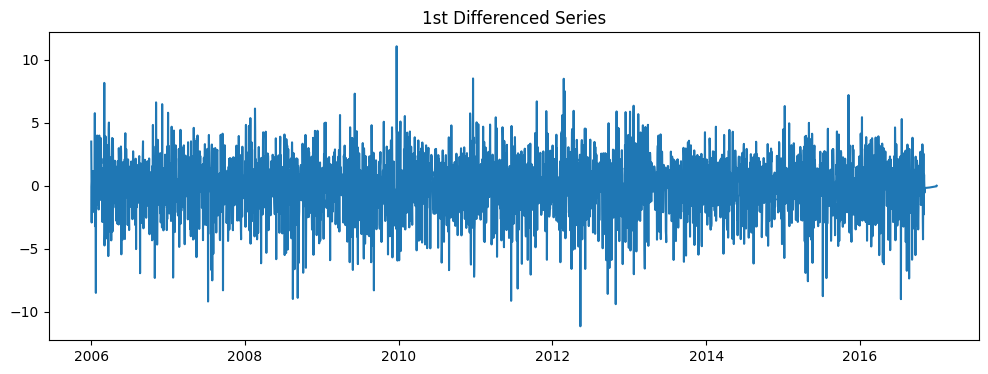

In [ ]:
from statsmodels.tsa.stattools import adfuller

# === STEP 3: STATIONARITY ===

# ADF test
result = adfuller(ts.dropna())
print("ADF Statistic:", result[0])
print("p-value:", result[1])

# Differencing if non-stationary
ts_diff = ts.diff().dropna()

result2 = adfuller(ts_diff)
print("After differencing → p-value:", result2[1])

# Plot differenced data
plt.figure(figsize=(12,4))
plt.plot(ts_diff)
plt.title("1st Differenced Series")
plt.show()


##STEP 4 — ACF & PACF (Identify ARIMA Orders)

<Figure size 1000x400 with 0 Axes>

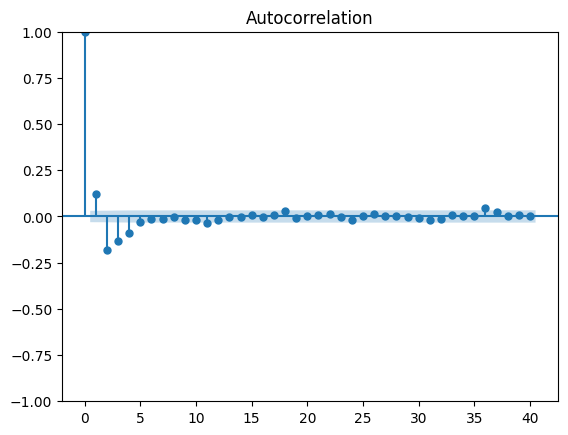

<Figure size 1000x400 with 0 Axes>

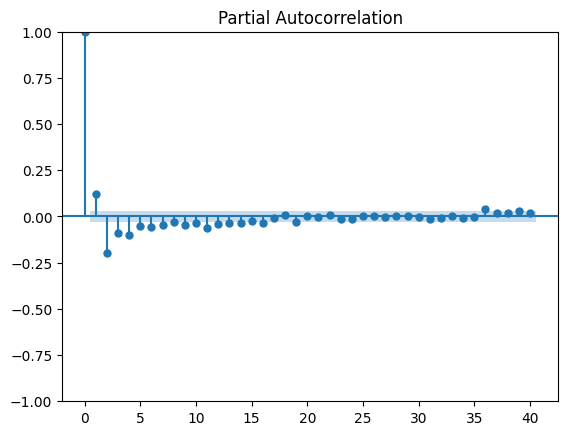

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# === STEP 4: ACF / PACF ===

plt.figure(figsize=(10,4))
plot_acf(ts_diff, lags=40)
plt.show()

plt.figure(figsize=(10,4))
plot_pacf(ts_diff, lags=40, method='ywm')
plt.show()


##STEP 5 — Train ARIMA Model

                               SARIMAX Results                                
Dep. Variable:        Temperature (C)   No. Observations:                 3416
Model:               SARIMAX(2, 1, 2)   Log Likelihood               -7427.313
Date:                Thu, 04 Dec 2025   AIC                          14864.625
Time:                        14:08:45   BIC                          14895.305
Sample:                    12-31-2005   HQIC                         14875.588
                         - 05-08-2015                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6753      0.065     10.355      0.000       0.547       0.803
ar.L2         -0.0321      0.061     -0.527      0.598      -0.152       0.087
ma.L1         -0.5836      0.064     -9.140      0.0

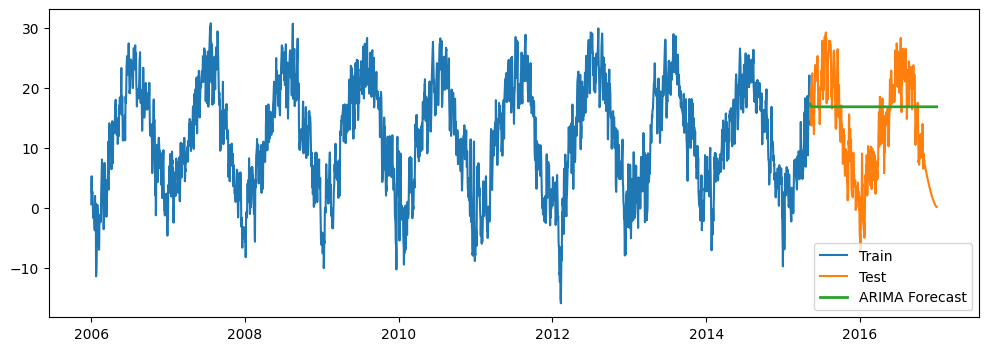

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import numpy as np

# === STEP 5: ARIMA ===

train_size = int(len(ts) * 0.85)
train = ts[:train_size]
test = ts[train_size:]

# Manual model (example p=2,d=1,q=2)
model_arima = SARIMAX(train, order=(2,1,2))
res_arima = model_arima.fit()

print(res_arima.summary())

# Forecast
pred_arima = res_arima.get_forecast(steps=len(test)).predicted_mean

# Plot
plt.figure(figsize=(12,4))
plt.plot(train, label="Train")
plt.plot(test, label="Test")
plt.plot(pred_arima, label="ARIMA Forecast", linewidth=2)
plt.legend()
plt.show()


##STEP 6 — Train SARIMA Model

                                     SARIMAX Results                                      
Dep. Variable:                    Temperature (C)   No. Observations:                 3416
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -7532.008
Date:                            Thu, 04 Dec 2025   AIC                          15074.017
Time:                                    14:09:41   BIC                          15104.679
Sample:                                12-31-2005   HQIC                         15084.975
                                     - 05-08-2015                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3917      0.072     -5.441      0.000      -0.533      -0.251
ma.L1          0.5587      0.065   

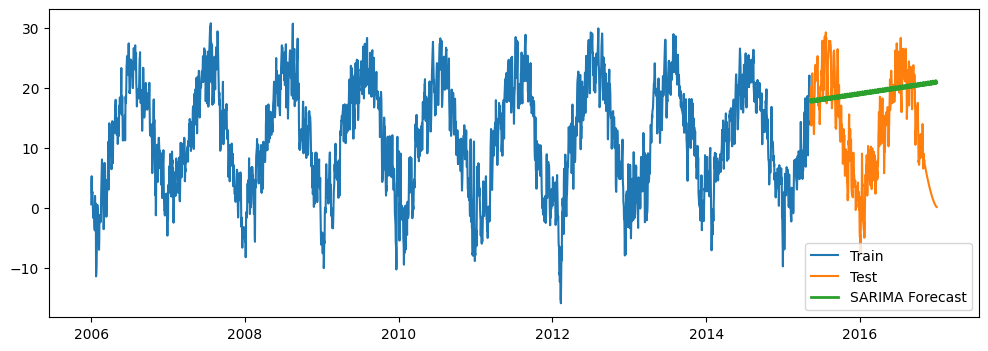

In [ ]:
# === STEP 6: SARIMA ===

model_sarima = SARIMAX(train,
                       order=(1,1,1),
                       seasonal_order=(1,1,1,12))   # 12 = 1 year seasonality (for monthly)
res_sarima = model_sarima.fit()

print(res_sarima.summary())

pred_sarima = res_sarima.get_forecast(steps=len(test)).predicted_mean

# Plot
plt.figure(figsize=(12,4))
plt.plot(train, label="Train")
plt.plot(test, label="Test")
plt.plot(pred_sarima, label="SARIMA Forecast", linewidth=2)
plt.legend()
plt.show()


##STEP 7 — Compare Both Models + Insights

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# === STEP 7: MODEL COMPARISON ===

rmse_arima = np.sqrt(mean_squared_error(test, pred_arima))
rmse_sarima = np.sqrt(mean_squared_error(test, pred_sarima))

mae_arima = mean_absolute_error(test, pred_arima)
mae_sarima = mean_absolute_error(test, pred_sarima)

print("\n--- Model Performance ---")
print("ARIMA → RMSE:", rmse_arima, " MAE:", mae_arima)
print("SARIMA → RMSE:", rmse_sarima, " MAE:", mae_sarima)

print("\nBest Model:", "SARIMA" if rmse_sarima < rmse_arima else "ARIMA")



--- Model Performance ---
ARIMA → RMSE: 9.173733714509707  MAE: 7.636591745067455
SARIMA → RMSE: 10.638815786007516  MAE: 8.557460933620327

Best Model: ARIMA
